In [2]:
import torch
import gpytorch
import botorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll, ExactMarginalLogLikelihood
from botorch.acquisition import qLogExpectedImprovement
from botorch.optim import optimize_acqf
import matplotlib.pyplot as plt
import pfns4bo
from pfns4bo.scripts.acquisition_functions import TransformerBOMethod
from tqdm import tqdm
from RFF import RFFSampler
from Aquisition_sampling import generate_sobol_points
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

/home/samuel/miniconda3/envs/PFN_research/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
rff_sampler = RFFSampler(10000, 5, 1, 1.0, "Matern32")
rff_sampler.omegas = rff_sampler.omegas.reshape(rff_sampler.num_features, rff_sampler.input_dim)

In [6]:
x1 = torch.linspace(0, 1, 500, dtype=torch.float64)
x2 = torch.linspace(0, 1, 500, dtype=torch.float64)

X1, X2 = torch.meshgrid(x1, x2, indexing='ij')

nums = torch.stack([X1.flatten(), X2.flatten()], dim=1)

function_samples = rff_sampler.sample(nums)
function_samples = function_samples.reshape([500, 500]).numpy()

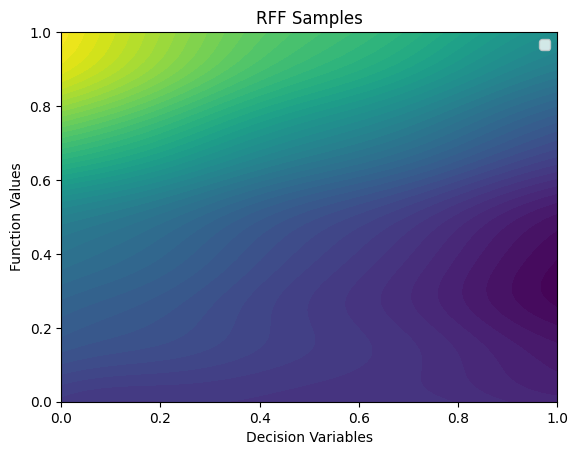

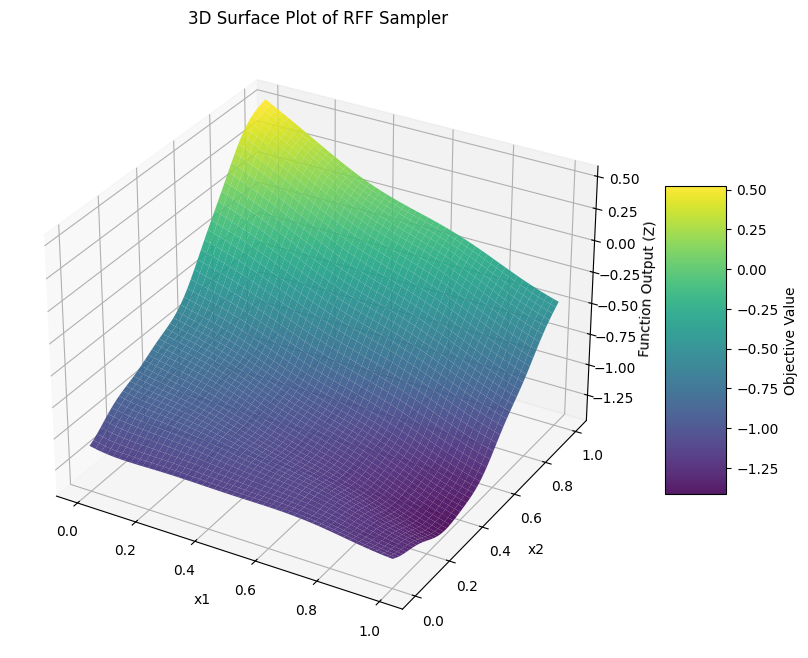

In [7]:
plt.contourf(X1.numpy(), X2.numpy(), function_samples, levels=50, cmap='viridis')
plt.xlabel('Decision Variables')
plt.ylabel('Function Values')
plt.title('RFF Samples')
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    X1.numpy(), 
    X2.numpy(), 
    function_samples, 
    cmap='viridis', 
    edgecolor='none', 
    alpha=0.9
)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Objective Value')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Function Output (Z)')
ax.set_title('3D Surface Plot of RFF Sampler')
plt.show()

In [7]:
x_train = torch.rand((20, 5), dtype=torch.float64)
y_train = rff_sampler.sample(x_train)

In [8]:
# Parameters
N_iters = 50
bounds = torch.Tensor([[0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0]])
q = 1
n_restarts = 1
n_samples = 100

In [9]:
# Setup PFN
model_path = pfns4bo.hebo_plus_model
pfn = TransformerBOMethod(torch.load(model_path, weights_only=False), device='cuda')

In [10]:
# Generate sampling scheme
x_test = generate_sobol_points(bounds.to(torch.float64), n_samples=1000, seed=42, device='cpu')

In [11]:
# BO loop
for i in tqdm(range(N_iters)):

    # Maximise Acquisition function
    f_best = y_train.max()
    candidate_idx, acq_value = pfn.observe_and_suggest(
        x_train,
        y_train,
        x_test,
        return_actual_ei=True
    )
    next_x = x_test[candidate_idx].unsqueeze(0)

    # Evaluate and add the new point to the training set
    next_y = rff_sampler.sample(next_x)
    x_train = torch.cat([x_train, next_x])
    y_train = torch.cat([y_train, next_y])

100%|██████████| 50/50 [00:03<00:00, 13.57it/s]


In [12]:
# BO loop
for i in tqdm(range(N_iters)):
    # Setup surrogate model
    model = SingleTaskGP(x_train, y_train)

    # Tune Hyperparams to maximise MLL
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # Maximise Acquisition function
    f_best = y_train.max()
    qEI = qLogExpectedImprovement(model, f_best)
    candidate, acq_value = optimize_acqf(acq_function=qEI, bounds=bounds, q=q, num_restarts=n_restarts, raw_samples=n_samples)
    next_x = candidate.to(dtype=torch.float64).detach()

    # Evaluate and add the new point to the training set
    next_y = rff_sampler.sample(next_x)
    x_train = torch.cat([x_train, next_x])
    y_train = torch.cat([y_train, next_y])

100%|██████████| 50/50 [00:19<00:00,  2.52it/s]
